HR_Analytics Employee Attrition Prediction Using Python, Pandas, and Sklearn

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import shap

In [59]:
df = pd.read_csv("HR_Attrition_Indian_Dataset.csv")
print(df)

       EmployeeID            FullName  Age  Gender Department  \
0     EMP20230001        Sahil Tailor   48   Other         HR   
1     EMP20230002  Parinaaz Choudhary   26  Female         IT   
2     EMP20230003          Anahi Babu   40    Male         IT   
3     EMP20230004          Dhruv Dass   54   Other         HR   
4     EMP20230005           Seher Bal   51   Other      Admin   
...           ...                 ...  ...     ...        ...   
4995  EMP20234996          Shlok Rege   60  Female   Accounts   
4996  EMP20234997          Sahil Rana   42   Other   Accounts   
4997  EMP20234998     Ranbir Bhandari   42  Female   Accounts   
4998  EMP20234999    Chirag Sabharwal   27   Other      Sales   
4999  EMP20235000         Shaan Edwin   40  Female      Sales   

            Designation EducationQualification  MonthlySalary DateOfJoining  \
0      Accounts Officer                 B.Tech         111813     5/26/2020   
1      Accounts Officer                 B.Tech          87425

Basic Analysis on the Datasets

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   EmployeeID              5000 non-null   object 
 1   FullName                5000 non-null   object 
 2   Age                     5000 non-null   int64  
 3   Gender                  5000 non-null   object 
 4   Department              5000 non-null   object 
 5   Designation             5000 non-null   object 
 6   EducationQualification  5000 non-null   object 
 7   MonthlySalary           5000 non-null   int64  
 8   DateOfJoining           5000 non-null   object 
 9   YearsWithCompany        5000 non-null   int64  
 10  YearsInRole             5000 non-null   int64  
 11  AppraisalRating         5000 non-null   int64  
 12  TrainingHours           5000 non-null   int64  
 13  DoesOvertime            5000 non-null   object 
 14  JobSatisfaction         5000 non-null   

In [61]:
df.describe()

,Age,MonthlySalary,YearsWithCompany,YearsInRole,AppraisalRating,TrainingHours,JobSatisfaction,WorkLifeBalance,PreviousCompanies,DistanceFromHome,LeavesTaken
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000
mean,40.710000,68200.896200,5.578600,2.820400,2.98820,30.07780,2.990800,2.50220,2.508800,25.47184,14.917800
std,11.361079,30290.742577,2.615414,2.443305,1.40216,17.55775,1.407662,1.11868,1.718753,14.19387,8.972912
min,22.000000,15031.000000,1.000000,0.000000,1.00000,0.00000,1.000000,1.00000,0.000000,1.00000,0.000000
25%,31.000000,42086.000000,3.000000,1.000000,2.00000,15.00000,2.000000,2.00000,1.000000,13.17500,7.000000
50%,41.000000,68358.500000,6.000000,2.000000,3.00000,30.00000,3.000000,2.50000,3.000000,25.50000,15.000000
75%,51.000000,94889.500000,8.000000,4.000000,4.00000,45.00000,4.000000,4.00000,4.000000,37.70000,23.000000
max,60.000000,119878.000000,10.000000,10.000000,5.00000,60.00000,5.000000,4.00000,5.000000,50.00000,30.000000


In [62]:
df.head()

,EmployeeID,FullName,Age,Gender,Department,Designation,EducationQualification,MonthlySalary,DateOfJoining,YearsWithCompany,...,TrainingHours,DoesOvertime,JobSatisfaction,WorkLifeBalance,MaritalStatus,PreviousCompanies,DistanceFromHome,LeavesTaken,City,LeftCompany
0,EMP20230001,Sahil Tailor,48,Other,HR,Accounts Officer,B.Tech,111813,5/26/2020,5,...,37,Yes,4,3,Single,0,12.2,4,Mumbai,No
1,EMP20230002,Parinaaz Choudhary,26,Female,IT,Accounts Officer,B.Tech,87425,10/2/2020,5,...,39,No,2,2,Divorced,0,36.7,29,Kolkata,No
2,EMP20230003,Anahi Babu,40,Male,IT,Software Engineer,Diploma,86461,5/1/2021,4,...,32,No,2,3,Married,1,45.4,0,Bengaluru,Yes
3,EMP20230004,Dhruv Dass,54,Other,HR,Accounts Officer,Diploma,23720,4/1/2023,2,...,21,Yes,4,4,Married,0,29.9,27,Kolkata,No
4,EMP20230005,Seher Bal,51,Other,Admin,Sales Associate,B.Tech,39041,12/19/2018,7,...,30,No,2,2,Single,0,26.8,6,Delhi,Yes


In [63]:
print("Total employees:", df.shape[0])
print("Total columns:", df.shape[1])

Total employees: 5000
Total columns: 22


In [64]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
EmployeeID                0
FullName                  0
Age                       0
Gender                    0
Department                0
Designation               0
EducationQualification    0
MonthlySalary             0
DateOfJoining             0
YearsWithCompany          0
YearsInRole               0
AppraisalRating           0
TrainingHours             0
DoesOvertime              0
JobSatisfaction           0
WorkLifeBalance           0
MaritalStatus             0
PreviousCompanies         0
DistanceFromHome          0
LeavesTaken               0
City                      0
LeftCompany               0
dtype: int64


In [65]:
print("Unique Departments:", df["Department"].unique())
print("Unique Job Roles:", df["Designation"].unique())

Unique Departments: ['HR' 'IT' 'Admin' 'Sales' 'Accounts']
Unique Job Roles: ['Accounts Officer' 'Software Engineer' 'Sales Associate' 'HR Executive'
 'Office Assistant']


In [66]:
df["Department"].value_counts()
df["Designation"].value_counts()

Designation
HR Executive         1049
Accounts Officer     1008
Software Engineer     995
Office Assistant      993
Sales Associate       955
Name: count, dtype: int64

In [67]:
df['LeftCompany'].value_counts()

LeftCompany
No     3145
Yes    1855
Name: count, dtype: int64

In [68]:
df.dtypes

EmployeeID                 object
FullName                   object
Age                         int64
Gender                     object
Department                 object
Designation                object
EducationQualification     object
MonthlySalary               int64
DateOfJoining              object
YearsWithCompany            int64
YearsInRole                 int64
AppraisalRating             int64
TrainingHours               int64
DoesOvertime               object
JobSatisfaction             int64
WorkLifeBalance             int64
MaritalStatus              object
PreviousCompanies           int64
DistanceFromHome          float64
LeavesTaken                 int64
City                       object
LeftCompany                object
dtype: object

In [69]:
df['DateOfJoining'] = pd.to_datetime(df['DateOfJoining'])

Exploratory Data Analysis - HR Analytics Prediction

In [70]:
sns.set(style="whitegrid")

C:\Users\Ayushi Srivastava\AppData\Local\Temp\ipykernel_1788\321302629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LeftCompany', data=df, palette='pastel')


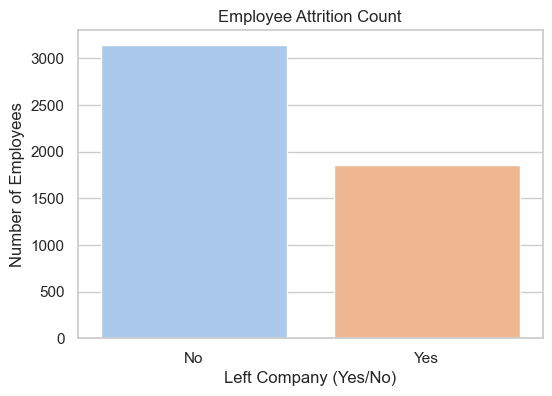

In [71]:
# Plot attrition (LeftCompany) count
plt.figure(figsize=(6,4))
sns.countplot(x='LeftCompany', data=df, palette='pastel')
plt.title("Employee Attrition Count")
plt.xlabel("Left Company (Yes/No)")
plt.ylabel("Number of Employees")
plt.show()

C:\Users\Ayushi Srivastava\AppData\Local\Temp\ipykernel_1788\1280030722.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LeftCompany', y='JobSatisfaction', data=df, palette='Accent')


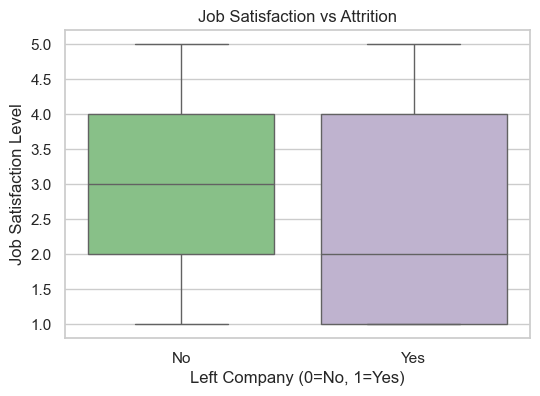

In [72]:
plt.figure(figsize=(6,4))
sns.boxplot(x='LeftCompany', y='JobSatisfaction', data=df, palette='Accent')
plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Left Company (0=No, 1=Yes)")
plt.ylabel("Job Satisfaction Level")
plt.show()

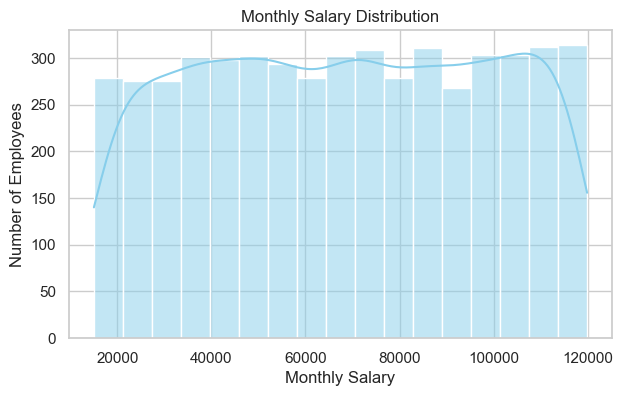

In [73]:
plt.figure(figsize=(7,4))
sns.histplot(df['MonthlySalary'], kde=True, color='skyblue')
plt.title("Monthly Salary Distribution")
plt.xlabel("Monthly Salary")
plt.ylabel("Number of Employees")
plt.show()

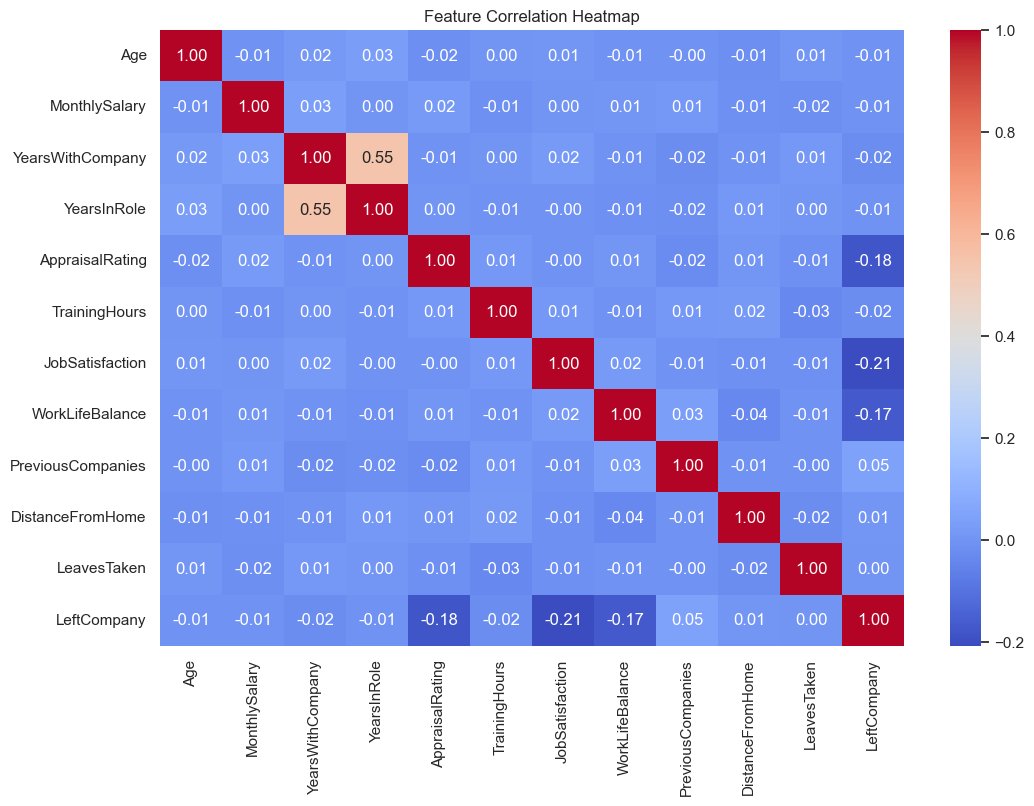

In [74]:
df['LeftCompany'] = df['LeftCompany'].map({'Yes': 1, 'No': 0})

num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [75]:
print("DF shape:", df.shape)
print("Columns and dtypes:\n")
print(df.dtypes)
print("\nFirst 5 rows:\n", df.head())

DF shape: (5000, 22)
Columns and dtypes:

EmployeeID                        object
FullName                          object
Age                                int64
Gender                            object
Department                        object
Designation                       object
EducationQualification            object
MonthlySalary                      int64
DateOfJoining             datetime64[ns]
YearsWithCompany                   int64
YearsInRole                        int64
AppraisalRating                    int64
TrainingHours                      int64
DoesOvertime                      object
JobSatisfaction                    int64
WorkLifeBalance                    int64
MaritalStatus                     object
PreviousCompanies                  int64
DistanceFromHome                 float64
LeavesTaken                        int64
City                              object
LeftCompany                        int64
dtype: object

First 5 rows:
     EmployeeID            

In [76]:
import pandas as pd

df = pd.read_csv("HR_Attrition_Indian_Dataset.csv")  
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

print("Unique values in LeftCompany:", df['LeftCompany'].unique())


Dataset shape: (5000, 22)
Columns: ['EmployeeID', 'FullName', 'Age', 'Gender', 'Department', 'Designation', 'EducationQualification', 'MonthlySalary', 'DateOfJoining', 'YearsWithCompany', 'YearsInRole', 'AppraisalRating', 'TrainingHours', 'DoesOvertime', 'JobSatisfaction', 'WorkLifeBalance', 'MaritalStatus', 'PreviousCompanies', 'DistanceFromHome', 'LeavesTaken', 'City', 'LeftCompany']
Unique values in LeftCompany: ['No' 'Yes']


In [77]:
df['LeftCompany'] = df['LeftCompany'].map({'Yes': 1, 'No': 0})

print("Unique values in LeftCompany after mapping:", df['LeftCompany'].unique())
print("Rows count:", df.shape[0])

Unique values in LeftCompany after mapping: [0 1]
Rows count: 5000


Encoding the Target columns and Categorical columns

In [78]:

df = df.drop(['EmployeeID', 'FullName'], axis=1)

df['DateOfJoining'] = pd.to_datetime(df['DateOfJoining'], errors='coerce')
df['YearsSinceJoining'] = (pd.Timestamp.now() - df['DateOfJoining']).dt.days / 365


df = df.drop(['DateOfJoining'], axis=1)


print(df.head())
print(df.dtypes)

   Age  Gender Department        Designation EducationQualification  \
0   48   Other         HR   Accounts Officer                 B.Tech   
1   26  Female         IT   Accounts Officer                 B.Tech   
2   40    Male         IT  Software Engineer                Diploma   
3   54   Other         HR   Accounts Officer                Diploma   
4   51   Other      Admin    Sales Associate                 B.Tech   

   MonthlySalary  YearsWithCompany  YearsInRole  AppraisalRating  \
0         111813                 5            0                3   
1          87425                 5            2                3   
2          86461                 4            4                2   
3          23720                 2            2                1   
4          39041                 7            1                1   

   TrainingHours DoesOvertime  JobSatisfaction  WorkLifeBalance MaritalStatus  \
0             37          Yes                4                3        Single   
1 

In [79]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object']).columns.tolist()
num_cols.remove('LeftCompany')  

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)


ct = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X = df.drop('LeftCompany', axis=1)
y = df['LeftCompany']


X_encoded = ct.fit_transform(X)


feature_names = ct.get_feature_names_out()
X_encoded = pd.DataFrame(X_encoded, columns=feature_names)

print("Encoded feature shape:", X_encoded.shape)

Categorical columns: ['Gender', 'Department', 'Designation', 'EducationQualification', 'DoesOvertime', 'MaritalStatus', 'City']
Numeric columns: ['Age', 'MonthlySalary', 'YearsWithCompany', 'YearsInRole', 'AppraisalRating', 'TrainingHours', 'JobSatisfaction', 'WorkLifeBalance', 'PreviousCompanies', 'DistanceFromHome', 'LeavesTaken', 'YearsSinceJoining']
Encoded feature shape: (5000, 35)


In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

scaler = StandardScaler()

num_numeric = 12  

X_train.iloc[:, -num_numeric:] = scaler.fit_transform(X_train.iloc[:, -num_numeric:])
X_test.iloc[:, -num_numeric:]  = scaler.transform(X_test.iloc[:, -num_numeric:])

print("Scaling complete.")

X_train shape: (4000, 35)
X_test shape: (1000, 35)
Scaling complete.


In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------- Logistic Regression --------
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("🔹 Logistic Regression Results 🔹")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# -------- Decision Tree --------
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("🔹 Decision Tree Results 🔹")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

🔹 Logistic Regression Results 🔹
Accuracy: 0.7

Confusion Matrix:
 [[541  88]
 [212 159]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.86      0.78       629
           1       0.64      0.43      0.51       371

    accuracy                           0.70      1000
   macro avg       0.68      0.64      0.65      1000
weighted avg       0.69      0.70      0.68      1000

🔹 Decision Tree Results 🔹
Accuracy: 0.669

Confusion Matrix:
 [[450 179]
 [152 219]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.72      0.73       629
           1       0.55      0.59      0.57       371

    accuracy                           0.67      1000
   macro avg       0.65      0.65      0.65      1000
weighted avg       0.67      0.67      0.67      1000



In [85]:
import shap

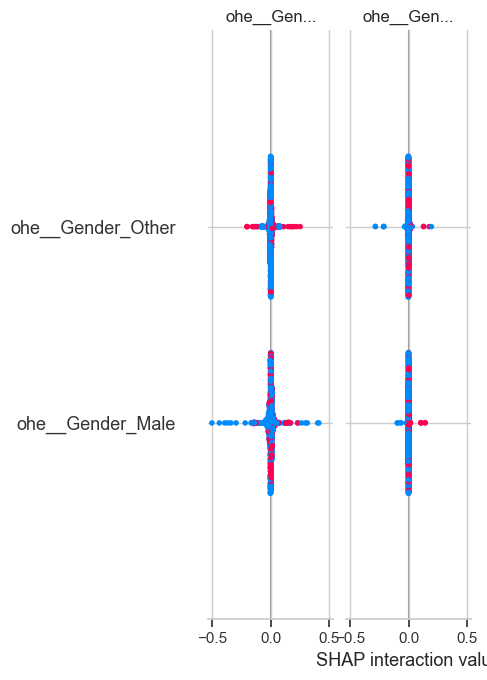

In [86]:
shap.summary_plot(shap_values, X_test)

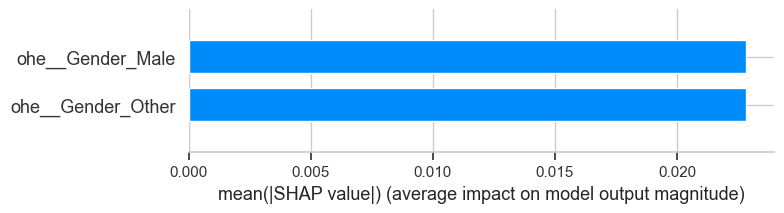

In [88]:
shap.summary_plot(shap_values[1], X_test.columns, plot_type="bar")

In [93]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.669


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]   

In [ ]:
final_df = X_test.copy()
final_df['Actual_Attrition'] = y_test.values
final_df['Predicted_Attrition'] = y_pred
final_df['Attrition_Probability'] = y_prob

In [92]:
final_df.to_csv('HR_Attrition_Predictions.csv', index=False)